# Load dữ liệu

In [1]:
import pandas as pd

train = pd.read_json("./train-preprocessed.json")
print(train.head())
print(train["sentiment"].value_counts())


                                              review sentiment
0  khu giau ha menh mong đuong song mua trua đuon...  negative
1  mau xe hybrid nissan kicks trieu viet pin chay...  negative
2  truong my yeu đam nga ukraine đot pha truong m...   neutral
3  đac gai hien than cuu me xet nghiem than phu h...  positive
4  chau ga đan vac truy am uc ngo đap chet ga uon...  negative
sentiment
neutral     771
negative    605
positive    579
Name: count, dtype: int64


# Tách X (text) và y (nhãn) + mã hoá nhãn

In [2]:
from sklearn.preprocessing import LabelEncoder

X_train_text = train["review"].astype(str)
y_train = train["sentiment"].astype(str)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

print("Classes:", le.classes_)        # ví dụ: ['negative' 'neutral' 'positive']
print("Encoded sample:", y_train_enc[:10])


Classes: ['negative' 'neutral' 'positive']
Encoded sample: [0 0 1 2 0 1 2 1 1 1]


# Xây pipeline: TF-IDF + XGBoost

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

num_classes = len(le.classes_)

xgb_clf = XGBClassifier(
    objective="multi:softprob",   # đa lớp, trả xác suất
    num_class=num_classes,
    # các tham số fix tạm, sẽ search 2 tham số chính bên dưới
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",           # nhanh hơn, nếu GPU thì có thể dùng 'gpu_hist'
    n_jobs=-1,
    eval_metric="mlogloss"
)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2)
    )),
    ("clf", xgb_clf)
])


GridSearchCV

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 6],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",   # đa lớp → macro-F1 hợp lý
    cv=cv,
    n_jobs=-1,
    verbose=2
)


In [5]:
grid.fit(X_train_text, y_train_enc)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,"Pipeline(step...ass=3, ...))])"
,param_grid,"{'clf__max_depth': [4, 6], 'clf__n_estimators': [200, 400]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [6]:
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

Best params: {'clf__max_depth': 4, 'clf__n_estimators': 400}
Best CV macro-F1: 0.6109792800908539


In [7]:
best_model = grid.best_estimator_

# Classification report trên tập test

In [8]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [9]:
test = pd.read_json("./test-preprocessed.json")
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)


In [10]:
# best model từ GridSearchCV
best_model = grid.best_estimator_   # Pipeline(tfidf + XGBClassifier)

# LabelEncoder đã fit ở bước train
# le: đã fit trên y_train (sentiment dạng text)


In [11]:
y_test_enc = le.transform(y_test_text)


In [12]:
y_pred_enc = best_model.predict(X_test_text)


In [13]:
acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

Accuracy trên test: 0.6135
Macro F1 trên test: 0.6107


In [14]:
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
)
print(report)


              precision    recall  f1-score   support

    negative       0.65      0.60      0.63       151
     neutral       0.58      0.68      0.63       193
    positive       0.64      0.53      0.58       145

    accuracy                           0.61       489
   macro avg       0.62      0.61      0.61       489
weighted avg       0.62      0.61      0.61       489



<Figure size 600x500 with 0 Axes>

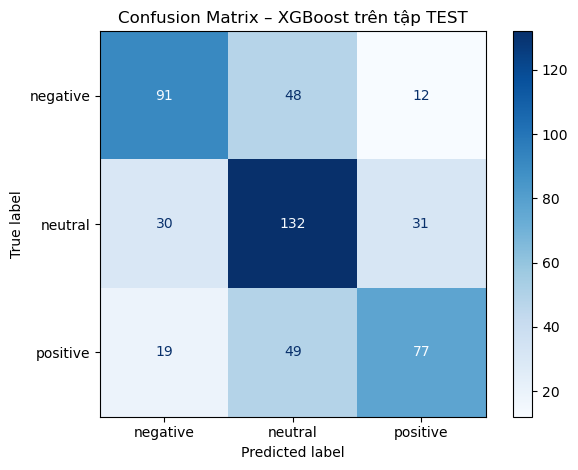

In [15]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title("Confusion Matrix – XGBoost trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()
